# 🗺️ S09 Station Graph — Alpha Explorer

> **S09 khác S07**: `graph.py` trả về 2 ma trận tĩnh:
> - `distances[i,j]` = khoảng cách Haversine (km)
> - `bearings[i,j]` = góc phương vị địa lý từ i→j (radian, [0, 2π))
>
> Graph động được tổng hợp ở đây bằng công thức:
> ```
> H[i,j]   = exp( -d²/σ² )                         ← khoảng cách
> W[i,j]   = (cos(bearing_ij − wind_dir_i) + 1) / 2  ← alignment gió [0,1]
> adj[i,j]  = H[i,j] * ((1−α) + α·W[i,j])           ← mixture
> ```
> **Mục tiêu**: Tìm `α` hợp lý bằng cách quan sát đồ thị.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm     as cm
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings; warnings.filterwarnings('ignore')

# ── Thêm path để import graph.py của S09 ────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath('')           # .../air-quality-forecasting/analysis
ROOT_DIR     = os.path.dirname(NOTEBOOK_DIR)  # .../air-quality-forecasting
S09_DIR      = os.path.join(ROOT_DIR, 'models', 'S09_XLinear_Clean')
ROOT_DIR     = os.path.dirname(os.path.dirname(S09_DIR))  # project root
sys.path.insert(0, S09_DIR)

DATA_DIR = os.path.join(ROOT_DIR, 'data')
INFO_PATH = os.path.join(DATA_DIR, 'info.csv')
WEATHER_DIR = os.path.join(DATA_DIR, 'raw', 'weather')

print('Root dir :', ROOT_DIR)
print('S09 dir  :', S09_DIR)
print('Data dir :', DATA_DIR)
print('info.csv :', os.path.exists(INFO_PATH))

Root dir : e:\University\Year 3 -2\DA2\CODE
S09 dir  : e:\University\Year 3 -2\DA2\CODE\models\S09_XLinear_Clean
Data dir : e:\University\Year 3 -2\DA2\CODE\data
info.csv : True


In [ ]:
# ── Import hàm tính distances & bearings từ graph.py S09 ────────────────────
from ..models.shared.graph_builder import get_base_matrices, haversine, calculate_bearing

cluster_north = [1, 2, 3, 4, 5, 6, 16, 17, 27, 28]   # 10 trạm
cluster_south = [7, 18, 24, 30, 31, 32]                # 6 trạm
SELECTED      = sorted(cluster_north + cluster_south)

# Tính distance + bearing tĩnh (từ toạ độ địa lý)
dist_mat, bear_mat = get_base_matrices(info_path=INFO_PATH,
                                        selected_stations=SELECTED)
print(f'Distance matrix : {dist_mat.shape}  max={dist_mat.max():.1f} km')
print(f'Bearing  matrix : {bear_mat.shape}  (radians, [0, 2π))')

ImportError: attempted relative import with no known parent package

In [ ]:
# ── Load toạ độ + thông tin trạm ────────────────────────────────────────────
df_info = pd.read_csv(INFO_PATH)
df_sel  = df_info[df_info['station'].isin(SELECTED)].copy()
df_sel['station'] = pd.Categorical(df_sel['station'], categories=SELECTED, ordered=True)
df_sel = df_sel.sort_values('station').reset_index(drop=True)

LATS = df_sel['latitude'].values
LONS = df_sel['longitude'].values
N    = len(SELECTED)

# ── Load hướng gió trung bình từ training set ────────────────────────────────
wind_dir = np.zeros(N)   # radian [0, 2π)
wind_spd = np.zeros(N)   # tốc độ gió đã chuẩn hoá (tương đối)

for k, sid in enumerate(SELECTED):
    fpath = os.path.join(WEATHER_DIR, f'weather_{sid}.csv')
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        wd_rad = np.deg2rad(df['wind_direction_10m (°)'])
        avg_sin = np.sin(wd_rad).mean()
        avg_cos = np.cos(wd_rad).mean()
        wind_dir[k] = (np.arctan2(avg_sin, avg_cos) + 2*np.pi) % (2*np.pi)
        if 'wind_speed_10m (m/s)' in df.columns:
            wind_spd[k] = df['wind_speed_10m (m/s)'].mean()
    else:
        print(f'⚠️ Thiếu dữ liệu gió trạm {sid}, gán mặc định (0)')
print('Wind direction loaded (radians):'); print(np.round(wind_dir, 3))

# ── Màu theo tỉnh ────────────────────────────────────────────────────────────
PROVINCE_COLOR = {
    'Ha Noi':    '#FF4C4C',
    'TP.HCM':    '#4DA6FF',
    'Da Nang':   '#FFB347',
    'Hai Phong': '#C084FC',
    'Can Tho':   '#4CAF50',
    'Dong Nai':  '#26C6DA',
    'Nam Dinh':  '#A1887F',
    'Nghe An':   '#90A4AE',
    'Tra Vinh':  '#F48FB1',
    'An Giang':  '#FFD54F',
}
node_colors = []
for sid in SELECTED:
    prov = df_info[df_info['station']==sid]['province'].values[0]
    node_colors.append(PROVINCE_COLOR.get(prov, '#AAAAAA'))

print('\nStations:', [f"S{s}" for s in SELECTED])

Wind direction loaded (radians):
[1.68  1.757 1.68  1.68  1.669 2.077 3.077 1.698 1.644 2.901 3.085 1.634
 1.071 2.957 2.732 3.259]

Stations: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S16', 'S17', 'S18', 'S24', 'S27', 'S28', 'S30', 'S31', 'S32']


In [ ]:
# ── Hàm xây dựng adjacency matrix ───────────────────────────────────────────

def build_adj(alpha=0.5):
    """
    adj[i,j] = H[i,j] * ((1-α) + α·W[i,j])

    H[i,j] = exp(-d²/σ²)                          ← chỉ khoảng cách
    W[i,j] = (cos(bearing_ij - wind_dir_i)+1)/2    ← alignment gió [0,1]
    α = 0  →  chỉ khoảng cách
    α = 1  →  khoảng cách × gió hoàn toàn
    """
    sigma2 = dist_mat[dist_mat > 0].std() ** 2
    H = np.exp(-dist_mat**2 / sigma2)   # Gaussian kernel
    np.fill_diagonal(H, 1.0)

    W = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            if i != j:
                angle_diff = bear_mat[i, j] - wind_dir[i]
                W[i, j] = (np.cos(angle_diff) + 1.0) / 2.0

    adj = H * ((1 - alpha) + alpha * W)
    np.fill_diagonal(adj, 1.0)
    return adj, H, W

adj0, H0, W0 = build_adj(0.5)
print(f'adj range (off-diag): [{adj0[adj0<1].min():.3f}, {adj0[adj0<1].max():.3f}]')

adj range (off-diag): [0.002, 0.998]


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# HÀM VẼ CHÍNH — nodes to, hiện cả khoảng cách + gió
# ════════════════════════════════════════════════════════════════════════════

def plot_graph(alpha=0.5, threshold=0.25, top_k=None,
               show_wind=True, show_dist_label=True,
               node_size=200, figsize=(22, 11)):
    """
    alpha       : float [0,1]  tỉ trọng hướng gió
    threshold   : float        chỉ vẽ cạnh adj > threshold
    top_k       : int|None     None = dùng threshold; int = top-K cạnh mỗi node
    show_wind   : bool         vẽ mũi tên gió (xanh lá)
    show_dist_label: bool      in số km trên cạnh gần nhất
    node_size   : int          kích thước node (scatter s=)
    """
    adj, H_mat, W_mat = build_adj(alpha)

    fig = plt.figure(figsize=figsize, facecolor='#0A0E1A')
    gs  = GridSpec(1, 2, width_ratios=[3.2, 1], figure=fig,
                   left=0.04, right=0.98, wspace=0.08)
    ax  = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax.set_facecolor('#0A0E1A')
    ax2.set_facecolor('#0A0E1A')

    cmap = cm.plasma

    # ── Vẽ cạnh (directed edges) ─────────────────────────────────────────────
    edge_count = 0
    for i in range(N):
        row = adj[i].copy(); row[i] = 0
        if top_k:
            keep = set(np.argsort(row)[::-1][:top_k])
            mask = np.array([j in keep for j in range(N)])
        else:
            mask = row > threshold

        for j in np.where(mask)[0]:
            w = adj[i, j]
            color = cmap(np.clip(w, 0, 1))
            lw    = 0.6 + w * 3.2
            alpha_line = 0.35 + w * 0.65

            ax.annotate("",
                xy=(LONS[j], LATS[j]),
                xytext=(LONS[i], LATS[i]),
                arrowprops=dict(
                    arrowstyle="->",
                    color=color, lw=lw, alpha=alpha_line,
                    connectionstyle="arc3,rad=0.09",
                    mutation_scale=14
                ),
                zorder=2
            )

            # Hiện khoảng cách km trên cạnh mạnh nhất
            if show_dist_label and w > 0.55:
                mx = (LONS[i] + LONS[j]) / 2
                my = (LATS[i] + LATS[j]) / 2
                d_km = dist_mat[i, j]
                ax.text(mx, my, f'{d_km:.0f}km',
                        color='#FFEB3B', fontsize=6.5,
                        ha='center', va='center', zorder=4,
                        bbox=dict(boxstyle='round,pad=0.1',
                                  fc='#0A0E1A', ec='none', alpha=0.6))
            edge_count += 1

    # ── Vẽ mũi tên hướng gió (màu xanh lá) ──────────────────────────────────
    WIND_SCALE = 0.32   # độ dài mũi tên (độ lon/lat)
    if show_wind:
        for k in range(N):
            wd = wind_dir[k]               # radians [0, 2π)
            # bearing → dx (lon), dy (lat)
            dx = np.sin(wd) * WIND_SCALE
            dy = np.cos(wd) * WIND_SCALE
            ax.annotate("",
                xy=(LONS[k] + dx, LATS[k] + dy),
                xytext=(LONS[k], LATS[k]),
                arrowprops=dict(
                    arrowstyle="->",
                    color='#00E676', lw=2.2, alpha=0.9,
                    mutation_scale=12
                ),
                zorder=5
            )

    # ── Vẽ node ─────────────────────────────────────────────────────────────
    for k in range(N):
        sid  = SELECTED[k]
        prov = df_info[df_info['station']==sid]['province'].values[0]
        dist = df_info[df_info['station']==sid]['district'].values[0]

        # Shadow / glow effect
        ax.scatter(LONS[k], LATS[k],
                   s=node_size * 1.8, c='white', alpha=0.08, zorder=6)

        ax.scatter(LONS[k], LATS[k],
                   s=node_size, c=node_colors[k], zorder=7,
                   edgecolors='white', linewidths=1.8)

        # Nhãn: tên trạm + khoảng cách tới trạm gần nhất
        row_d = dist_mat[k].copy(); row_d[k] = np.inf
        nearest_km = row_d.min()

        ax.text(LONS[k], LATS[k] + 0.18,
                f'S{sid}', color='white',
                fontsize=9, fontweight='bold',
                ha='center', va='bottom', zorder=8)
        ax.text(LONS[k], LATS[k] - 0.22,
                dist.strip(), color='#BBBBBB',
                fontsize=6.5, ha='center', va='top', zorder=8)

    # ── Colorbar ─────────────────────────────────────────────────────────────
    sm = cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(0, 1))
    cb = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.01)
    cb.set_label('Edge Weight  adj[i,j]', color='white', fontsize=9)
    cb.ax.yaxis.set_tick_params(color='white')
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')

    ax.set_xlabel('Kinh độ (Longitude)', color='#AAAAAA', fontsize=10)
    ax.set_ylabel('Vĩ độ  (Latitude)',   color='#AAAAAA', fontsize=10)
    ax.tick_params(colors='#888888')
    for sp in ax.spines.values(): sp.set_edgecolor('#2A2F45')

    title = (f'Station Graph  │  α_wind = {alpha:.2f}'
             f'  │  edges = {edge_count}  │  '
             + (f'top-{top_k}/node' if top_k else f'threshold = {threshold:.2f}'))
    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=14)

    # ── Legend tỉnh + ký hiệu gió ─────────────────────────────────────────
    seen = {}
    for k, sid in enumerate(SELECTED):
        p = df_info[df_info['station']==sid]['province'].values[0]
        if p not in seen: seen[p] = node_colors[k]

    handles = [plt.scatter([], [], s=120, c=c, label=p, edgecolors='white', linewidths=1)
               for p, c in seen.items()]
    if show_wind:
        handles.append(plt.Line2D([0],[0], color='#00E676', lw=2.2,
                                   label='Hướng gió '))
    if show_dist_label:
        handles.append(mpatches.Patch(color='#FFEB3B', label='Khoảng cách (km)'))

    ax.legend(handles=handles, loc='center left',
              facecolor='#131929', labelcolor='white',
              fontsize=8, framealpha=0.85)

    # ── Panel phải: Adjacency heatmap (cả adj, H, W) ─────────────────────
    ax2.set_facecolor('#0A0E1A')
    im = ax2.imshow(adj, cmap='plasma', vmin=0, vmax=1, aspect='auto')
    ticks = range(N)
    labels = [f'S{s}' for s in SELECTED]
    ax2.set_xticks(ticks); ax2.set_yticks(ticks)
    ax2.set_xticklabels(labels, rotation=90, fontsize=7, color='white')
    ax2.set_yticklabels(labels, fontsize=7, color='white')
    ax2.set_title(f'Adjacency Matrix (α={alpha:.2f})',
                  color='white', fontsize=9, pad=6)
    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04).ax.yaxis.set_tick_params(color='white')

    plt.savefig(f'graph_a{alpha:.2f}.png', dpi=140,
                bbox_inches='tight', facecolor='#0A0E1A')
    plt.show()
    print(f'✅  Saved → graph_a{alpha:.2f}.png   edges={edge_count}')
    off = adj[np.eye(N)==0]
    print(f'   adj off-diag: mean={off.mean():.4f}  std={off.std():.4f}'
          f'  min={off.min():.4f}  max={off.max():.4f}')

print('plot_graph() defined ✓')

plot_graph() defined ✓


---
## ▶️ Chạy ô dưới để vẽ graph — thay đổi `ALPHA` để thử nghiệm

| Tham số | Mô tả |
|---|---|
| `ALPHA` | 0 = chỉ khoảng cách · 1 = khoảng cách × gió hoàn toàn |
| `THRESH` | Ngưỡng weight để hiện cạnh (`None` nếu dùng `TOP_K`) |
| `TOP_K`  | Giữ top-K cạnh mạnh nhất cho mỗi node (`None` = dùng THRESH) |
| `NODE_SIZE` | Kích thước node (mặc định 600) |

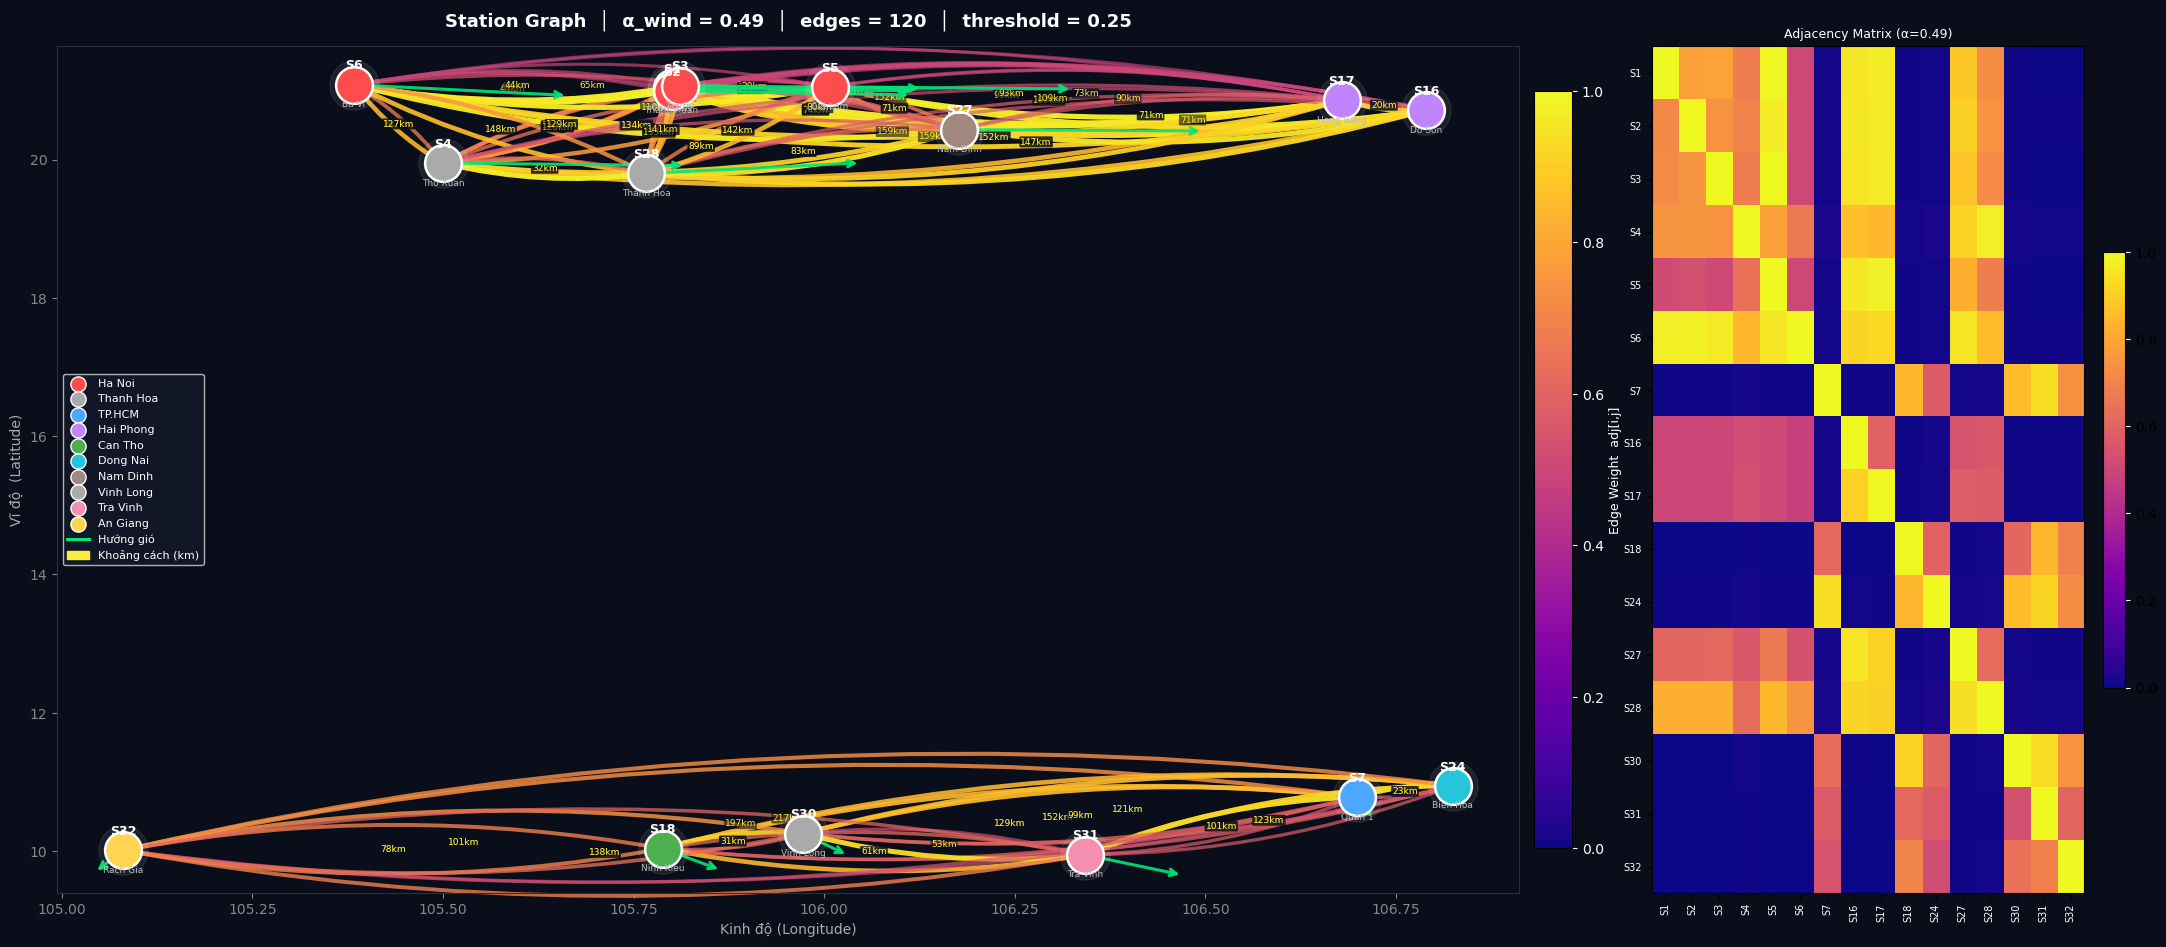

✅  Saved → graph_a0.49.png   edges=120
   adj off-diag: mean=0.3713  std=0.3830  min=0.0023  max=0.9985


In [ ]:
# ═══════════════════════════════════════════════════
#   ✏️  THAY ĐỔI THAM SỐ TẠI ĐÂY
# ═══════════════════════════════════════════════════
ALPHA     = 0.4858      # [0.0 → 1.0]
THRESH    = 0.25     # chỉ vẽ cạnh > THRESH
TOP_K     = None     # None = dùng THRESH
WIND      = True     # hiện mũi tên gió xanh
DIST_LBL  = True     # hiện nhãn km trên cạnh mạnh
NODE_SIZE = 700      # kích thước node

plot_graph(alpha=ALPHA, threshold=THRESH, top_k=TOP_K,
           show_wind=WIND, show_dist_label=DIST_LBL,
           node_size=NODE_SIZE)

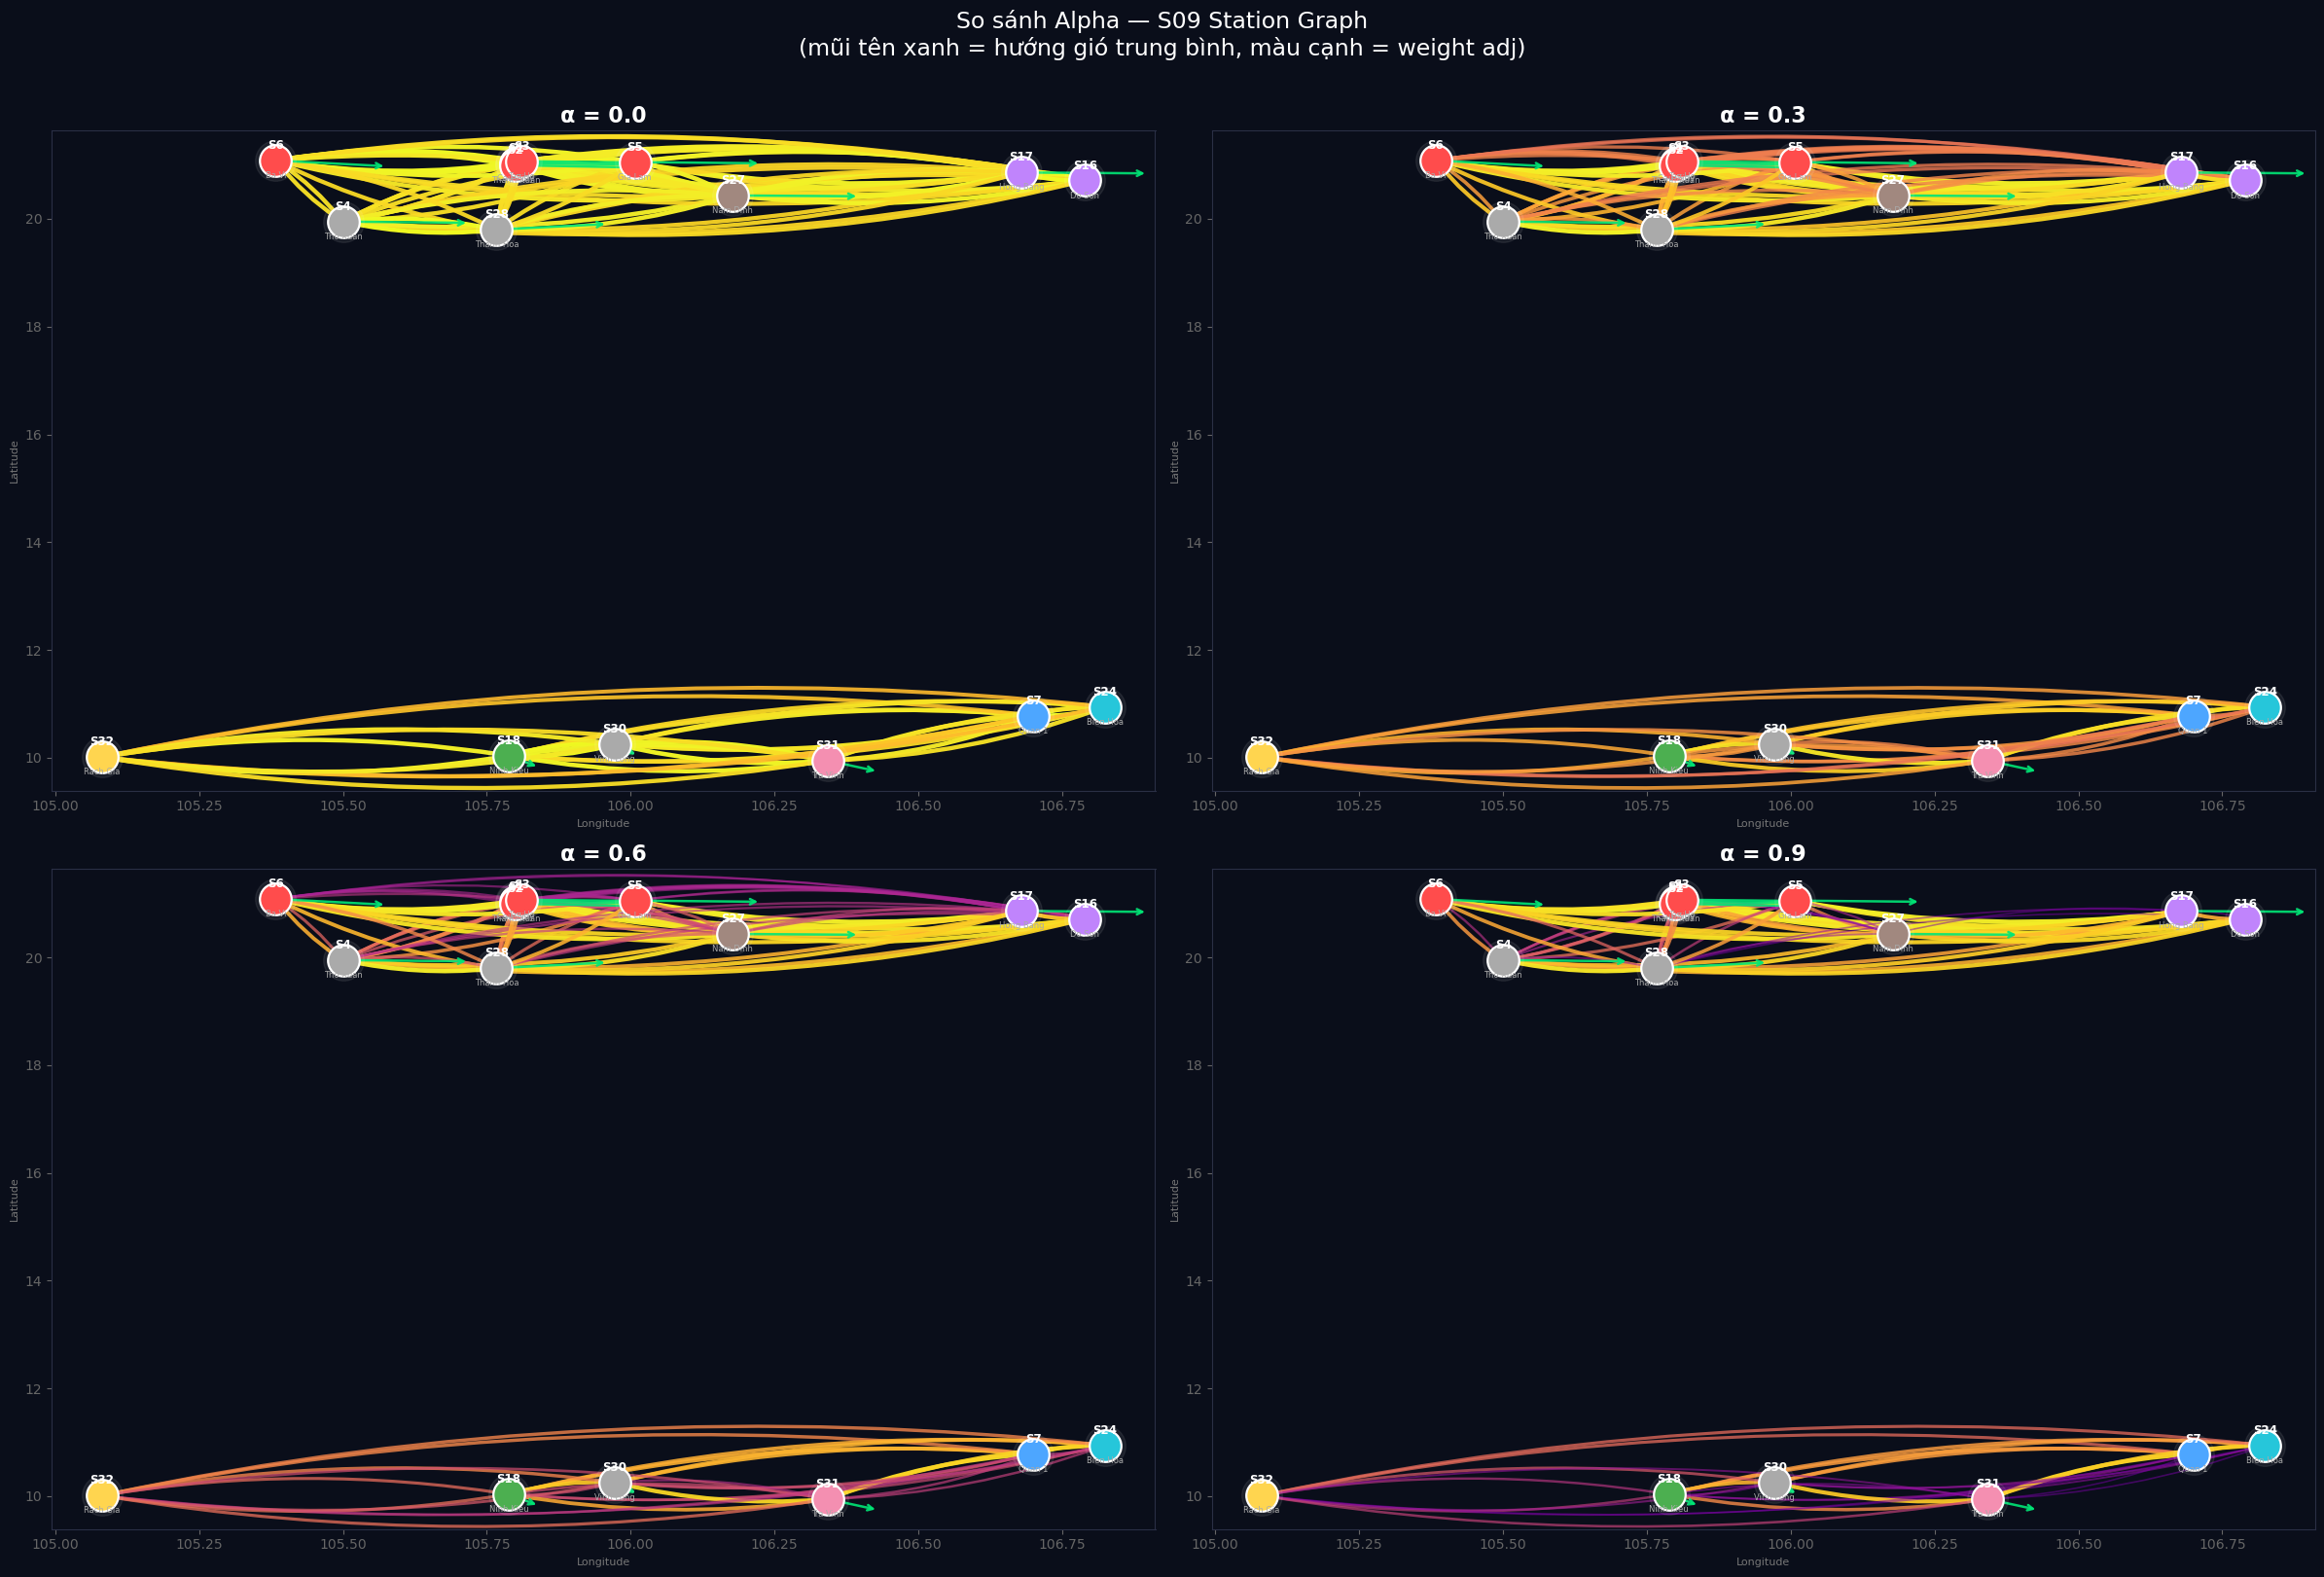

✅  Saved → graph_comparison_4alpha.png


In [ ]:
# ── So sánh 4 mức alpha ──────────────────────────────────────────────────────
ALPHAS = [0.0, 0.3, 0.6, 0.9]

fig, axes = plt.subplots(2, 2, figsize=(24, 16),
                          facecolor='#0A0E1A',
                          subplot_kw={'facecolor':'#0A0E1A'})

for ax, a in zip(axes.flat, ALPHAS):
    adj_a, _, _ = build_adj(a)
    cmap = cm.plasma

    # cạnh
    for i in range(N):
        for j in range(N):
            if i == j: continue
            w = adj_a[i, j]
            if w < 0.22: continue
            col = cmap(w)
            ax.annotate("",
                xy=(LONS[j], LATS[j]),
                xytext=(LONS[i], LATS[i]),
                arrowprops=dict(
                    arrowstyle="->", color=col,
                    lw=0.5 + w*2.8, alpha=0.35+w*0.65,
                    connectionstyle="arc3,rad=0.08",
                    mutation_scale=11
                ), zorder=2
            )

    # gió
    for k in range(N):
        wd = wind_dir[k]
        dx = np.sin(wd) * 0.22; dy = np.cos(wd) * 0.22
        ax.annotate("",
            xy=(LONS[k]+dx, LATS[k]+dy),
            xytext=(LONS[k], LATS[k]),
            arrowprops=dict(arrowstyle="->", color='#00E676',
                            lw=1.8, alpha=0.9, mutation_scale=10),
            zorder=5
        )

    # nodes
    for k in range(N):
        sid = SELECTED[k]
        ax.scatter(LONS[k], LATS[k], s=550, c=node_colors[k],
                   edgecolors='white', linewidths=1.6, zorder=7)
        ax.scatter(LONS[k], LATS[k], s=900, c='white',
                   alpha=0.07, zorder=6)
        ax.text(LONS[k], LATS[k]+0.16, f'S{sid}',
                color='white', fontsize=8.5, fontweight='bold',
                ha='center', va='bottom', zorder=8)
        dist_name = df_info[df_info['station']==sid]['district'].values[0].strip()
        ax.text(LONS[k], LATS[k]-0.2, dist_name,
                color='#AAAAAA', fontsize=6, ha='center', va='top', zorder=8)

    ax.set_title(f'α = {a:.1f}', color='white', fontsize=16, fontweight='bold')
    ax.tick_params(colors='#666')
    for sp in ax.spines.values(): sp.set_edgecolor('#2A2F45')
    ax.set_xlabel('Longitude', color='#777', fontsize=8)
    ax.set_ylabel('Latitude',  color='#777', fontsize=8)

fig.suptitle('So sánh Alpha — S09 Station Graph\n'
             '(mũi tên xanh = hướng gió trung bình, màu cạnh = weight adj)',
             color='white', fontsize=17, y=1.01)
plt.tight_layout()
plt.savefig('graph_comparison_4alpha.png', dpi=130,
            bbox_inches='tight', facecolor='#0A0E1A')
plt.show()
print('✅  Saved → graph_comparison_4alpha.png')

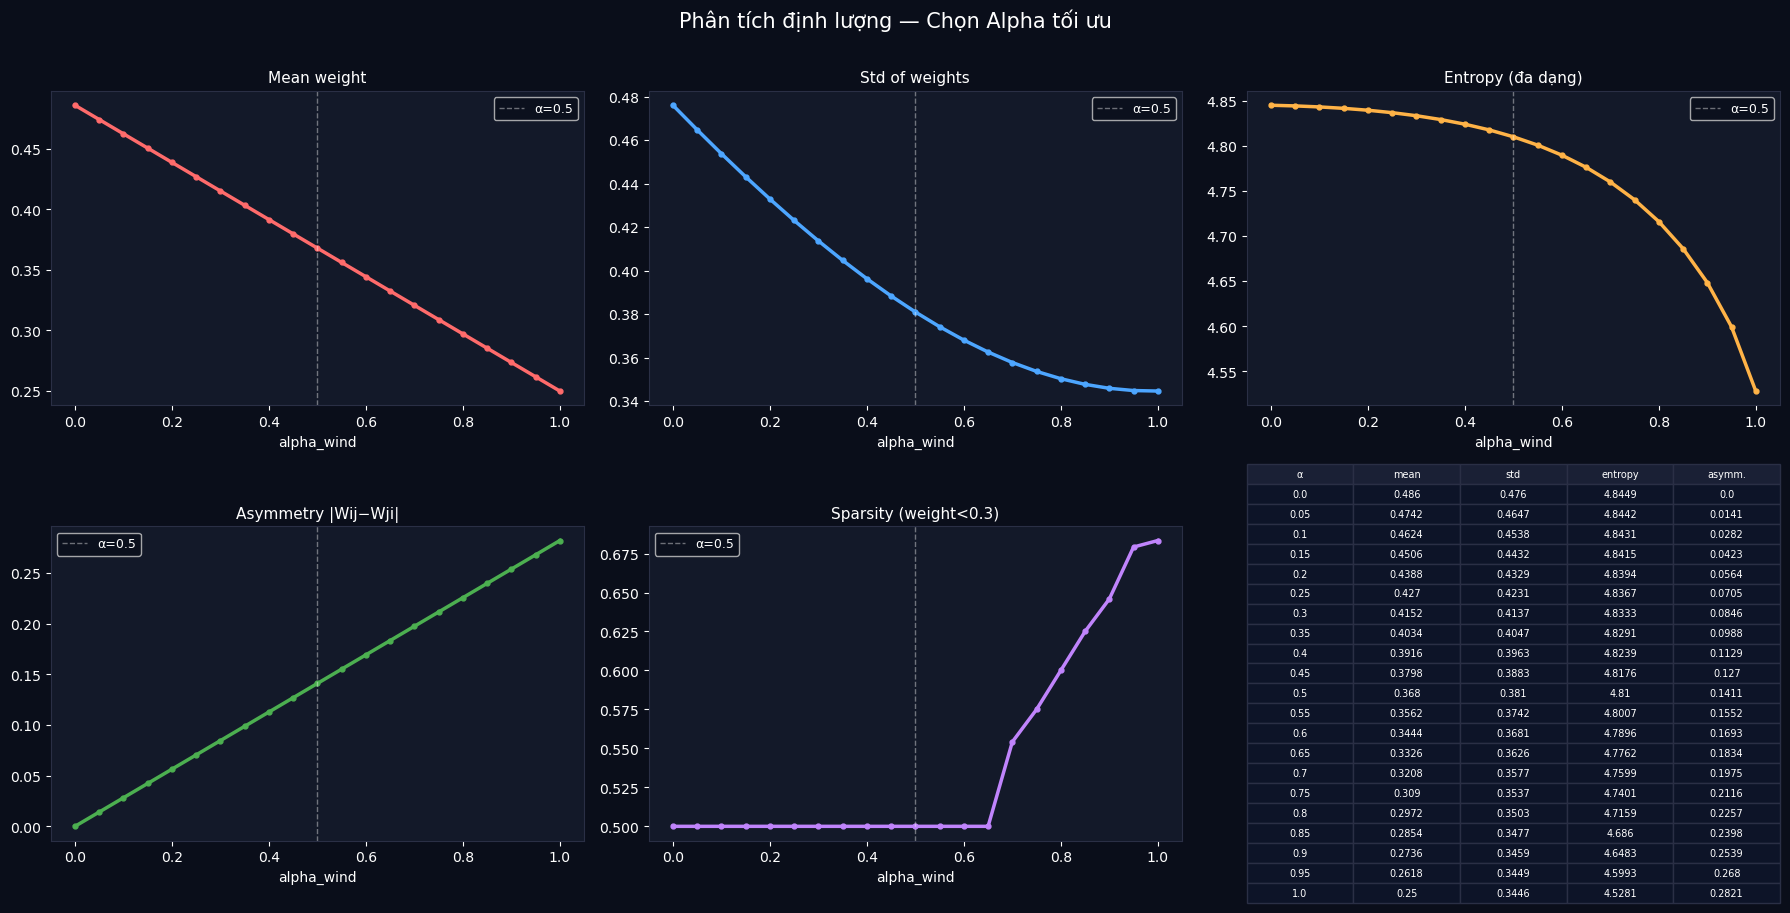

✅  Saved → graph_alpha_analysis.png


In [ ]:
# ── Phân tích định lượng alpha 0→1 ──────────────────────────────────────────
alpha_range = np.arange(0.0, 1.05, 0.05)   # Step = 0.05 (Quét 21 điểm alpha)
records = []
for a in alpha_range:
    adj_a, H_a, W_a = build_adj(a)
    off = adj_a[np.eye(N)==0]
    # Bất đối xứng (directed-ness)
    asym = np.abs(adj_a - adj_a.T)
    np.fill_diagonal(asym, 0)
    # Entropy
    p = off / off.sum()
    entropy = -np.sum(p * np.log(p + 1e-12))
    records.append({
        'alpha':      a,
        'mean':       off.mean(),
        'std':        off.std(),
        'entropy':    entropy,
        'asymmetry':  asym.mean(),
        'sparse_30':  (off < 0.30).mean(),
    })

df_q = pd.DataFrame(records)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), facecolor='#0A0E1A',
                          subplot_kw={'facecolor':'#131929'})
metrics = ['mean','std','entropy','asymmetry','sparse_30']
titles  = ['Mean weight','Std of weights',
           'Entropy (đa dạng)','Asymmetry |Wij−Wji|',
           'Sparsity (weight<0.3)']
colors  = ['#FF6B6B','#4DA6FF','#FFB347','#4CAF50','#C084FC']

for ax, m, t, c in zip(axes.flat[:5], metrics, titles, colors):
    ax.plot(df_q['alpha'], df_q[m], color=c, lw=2.5, marker='o', ms=3.5)
    ax.axvline(0.5, color='white', lw=1, ls='--', alpha=0.4, label='α=0.5')
    ax.set_xlabel('alpha_wind', color='white')
    ax.set_title(t, color='white', fontsize=11)
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#2A2F45')
    ax.legend(labelcolor='white', facecolor='#0A0E1A', fontsize=9)

# Panel cuối: bảng tóm tắt
ax6 = axes.flat[5]; ax6.axis('off')
rows = df_q.copy()
rows = rows.round(4)
table = ax6.table(
    cellText=rows[['alpha','mean','std','entropy','asymmetry']].values,
    colLabels=['α','mean','std','entropy','asymm.'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False); table.set_fontsize(7)
table.scale(1, 1.2)
for (r,c), cell in table.get_celld().items():
    cell.set_facecolor('#1A2035' if r==0 else '#0D1428')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#2A2F45')
ax6.set_title('', color='white', fontsize=10)

fig.suptitle('Phân tích định lượng — Chọn Alpha tối ưu',
             color='white', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('graph_alpha_analysis.png', dpi=130,
            bbox_inches='tight', facecolor='#0A0E1A')
plt.show()
print('✅  Saved → graph_alpha_analysis.png')

In [ ]:
# ── Top edges theo từng alpha ────────────────────────────────────────────────
def top_edges(alpha=0.5, top=12):
    adj_a, _, _ = build_adj(alpha)
    edges = []
    for i in range(N):
        for j in range(N):
            if i != j:
                edges.append((SELECTED[i], SELECTED[j],
                               dist_mat[i,j], adj_a[i,j]))
    edges.sort(key=lambda x: -x[3])
    print(f'\n🏆  Top-{top} cạnh mạnh nhất  (alpha={alpha}):')
    print(f'{"From":>9} → {"To":<9}  {"Dist(km)":>10}  {"Weight":>8}')
    print('─'*45)
    for s, d, km, w in edges[:top]:
        ps = df_info[df_info['station']==s]['district'].values[0].strip()
        pd_ = df_info[df_info['station']==d]['district'].values[0].strip()
        print(f'S{s:2d}({ps:<8}) → S{d:2d}({pd_:<8})  {km:>8.1f} km  {w:>8.4f}')

top_edges(0.0, 10)
top_edges(0.5, 10)
top_edges(0.9, 10)


🏆  Top-10 cạnh mạnh nhất  (alpha=0.0):
     From → To           Dist(km)    Weight
─────────────────────────────────────────────
S 1(Cau Giay) → S 2(Thanh Xuan)       4.2 km    0.9999
S 2(Thanh Xuan) → S 1(Cau Giay)       4.2 km    0.9999
S 1(Cau Giay) → S 3(Tay Ho  )       4.2 km    0.9999
S 3(Tay Ho  ) → S 1(Cau Giay)       4.2 km    0.9999
S 2(Thanh Xuan) → S 3(Tay Ho  )       8.3 km    0.9998
S 3(Tay Ho  ) → S 2(Thanh Xuan)       8.3 km    0.9998
S16(Do Son  ) → S17(Hong Bang)      20.0 km    0.9986
S17(Hong Bang) → S16(Do Son  )      20.0 km    0.9986
S 3(Tay Ho  ) → S 5(Gia Lam )      20.5 km    0.9985
S 5(Gia Lam ) → S 3(Tay Ho  )      20.5 km    0.9985

🏆  Top-10 cạnh mạnh nhất  (alpha=0.5):
     From → To           Dist(km)    Weight
─────────────────────────────────────────────
S 3(Tay Ho  ) → S 5(Gia Lam )      20.5 km    0.9984
S 1(Cau Giay) → S 5(Gia Lam )      21.5 km    0.9924
S 6(Ba Vi   ) → S 2(Thanh Xuan)      44.3 km    0.9832
S 5(Gia Lam ) → S17(Hong Bang)      73.

---
## 📌 Kết luận chọn Alpha

| Alpha | Đặc điểm |
|---|---|
| **0.0** | Chỉ khoảng cách — graph đối xứng, đơn giản |
| **0.3–0.5** | Cân bằng — gió tăng asymmetry nhẹ, hợp lý cho KNN |
| **0.7–0.9** | Gió chiếm ưu thế — directed graph rõ hướng, phù hợp STGCN |
| **1.0** | Chỉ gió × khoảng cách — nhiều cạnh yếu, graph thưa |

**Khuyến nghị**: Thử `α ∈ {0.3, 0.5, 0.7}` và so sánh RMSE validation.